In [2]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [3]:
flat_hudl = fits.open('data/flat.fits')
flat_data = flat_hudl[0].data
print(flat_data.shape)

(4112, 385)


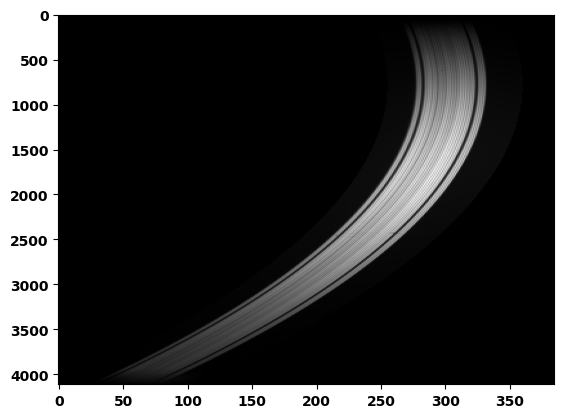

In [4]:
plt.imshow(flat_data,aspect = 'auto',cmap = 'grey')

In [5]:
%matplotlib widget

0

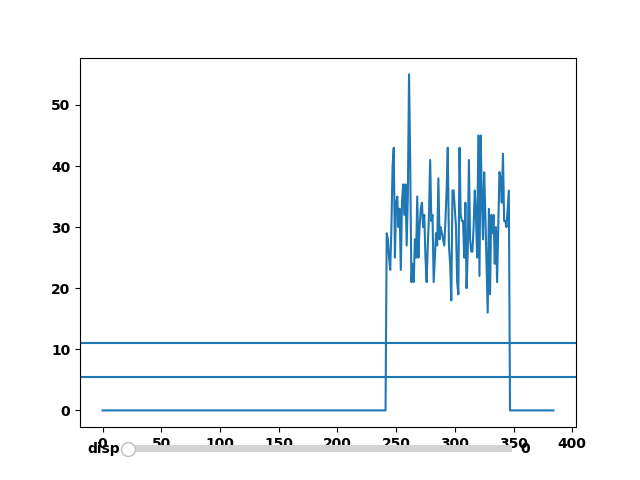

In [37]:
fig,ax = plt.subplots()
fctr_low = 0.1
fctr_high = 0.2
lines=[ax.plot(flat_data[0]),ax.axhline(y=fctr_low*max(flat_data[0])),ax.axhline(y=fctr_high*max(flat_data[0]))]
ax_slider = fig.add_axes([0.2, 0.05, 0.6, 0.03])
disp_slider = Slider(ax=ax_slider,valmin=0,valmax=len(flat_data[:,0])-1,valinit=0,label='disp')
def update(val):
    val=int(val)
    lines[0][0].set_ydata(flat_data[val])
    lines[1].set_ydata([fctr_low*max(flat_data[val]),fctr_low*max(flat_data[val])])
    lines[2].set_ydata([fctr_high*max(flat_data[val]),fctr_high*max(flat_data[val])])
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

disp_slider.on_changed(update)

In [35]:
left_edges = []
right_edges = []
idxs = []
for i, row in enumerate(flat_data):
    threshold_low = 0.1*np.max(row)
    threshold_high = 0.2*np.max(row)
    tracks, = np.where((row<threshold_high) & (row>threshold_low))
    if len(tracks) != 2:
        continue
    if abs(tracks[0]-tracks[1])<15:
        continue
    print(tracks[0]-tracks[1])
    left_edges.append(min(tracks))
    right_edges.append(max(tracks))
    idxs.append(i)

-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-42
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-42
-41
-41
-41
-41
-41
-41
-41
-41
-42
-41
-41
-41
-41
-41
-41
-41
-41
-41
-42
-41
-41
-41
-41
-41
-41
-41
-41
-41
-41
-42
-41
-41


In [39]:
for order in range(5):
    left_p = np.polyfit(idxs,left_edges,order)
    right_p = np.polyfit(idxs,right_edges,order)
    left_model = np.polyval(left_p,idxs)
    right_model = np.polyval(right_p,idxs)
    chi2_left = np.sum((left_model-left_edges)**2)
    chi2_right = np.sum((right_model-right_edges)**2)
    print(order)
    print(f"left RSS: {chi2_left}")
    print(f"right RSS: {chi2_right}")

0
left RSS: 4152222.938202247
right RSS: 4124594.488764045
1
left RSS: 475709.78435223945
right RSS: 467504.5336269655
2
left RSS: 39.71236129465386
right RSS: 155.0262890484903
3
left RSS: 24.15891021196955
right RSS: 148.03835211531282
4
left RSS: 22.964639612228105
right RSS: 147.21968155712602


as per the previous cell, a 2nd degree polynomial provides a much better fit than liner or constant fits, but higher order polynomials do not provide a meaningful increace in goodness of fit for the extra comptaitional cost

In [40]:
left_p = np.polyfit(idxs,left_edges,2)
right_p = np.polyfit(idxs,right_edges,2)

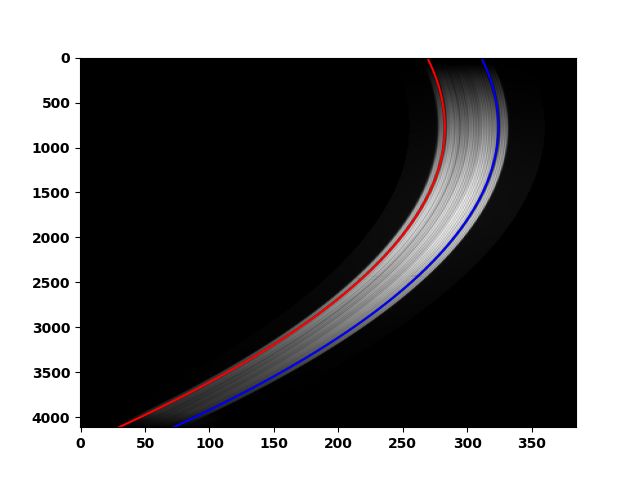

In [41]:
fig,ax = plt.subplots()
ax.imshow(flat_data,aspect='auto',cmap='grey')
idxs = range(len(flat_data[:,0]))
ax.plot(np.polyval(left_p,idxs),idxs,c='r')
ax.plot(np.polyval(right_p,idxs),idxs,c='b')